# Baseline MobileNetV2 - No Augmentation

Before starting, I'd like to make note of the class imbalances across all the image sets:

Key: 0 = benign, 1 = malignant

- Train
    - 0: 1,569 images 
    - 1: 803 images
    
- Validation
    - 0: 448 images 
    - 1: 227 images
    
- Test
    - 0: 208 images 
    - 1: 128 images

I'll be monitoring recall during the epochs and evaluating model performance using training vs validation graphs and ROC-AUC curves.

# Model Training

In [1]:
import tensorflow as tf
import keras
from tensorflow.keras import layers, optimizers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt
import numpy as np
import pickle

2025-07-30 09:33:02.968396: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-30 09:33:02.986093: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 09:33:03.087463: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 09:33:03.156761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753885983.216135    3288 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753885983.23

In [2]:
# Setting some variables 
image_size = (224, 224)
batch_size = 10
seed = 42

# Load in the training set
train_ds = keras.utils.image_dataset_from_directory(
    "train",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    seed=seed)

# Load in the validation set
valid_ds = keras.utils.image_dataset_from_directory(
    "valid",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    seed=seed)

Found 2372 files belonging to 2 classes.
Found 675 files belonging to 2 classes.


2025-07-30 09:33:07.578240: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


2025-07-30 09:33:08.102124: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


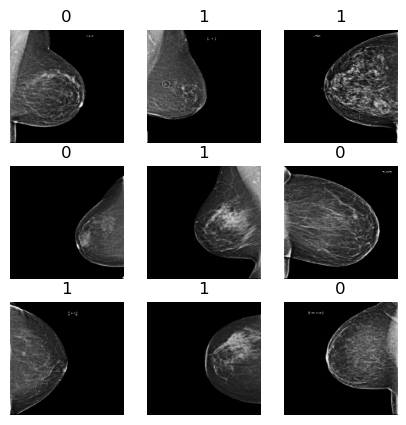

In [3]:
# Display some of the images from training
plt.figure(figsize=(5, 5))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

Now, time to create and train a MobileNetV2 model

In [4]:
# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
valid_ds = valid_ds.prefetch(tf_data.AUTOTUNE)

In [5]:
# Function that creates a MobileNetV2 model 
def make_transfer_model(input_shape):
    
    # Load the pre-trained weights of MobileNetV2 and freeze the weights
    backbone = keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,)
    
    backbone.trainable = False

    inputs = layers.Input(input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dropout(0.25)(x)
    
    units = 1
    outputs = layers.Dense(units, activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="keypoint_detector")

In [6]:
baseline = make_transfer_model(input_shape=(224,224) + (3,))

In [7]:
# Set the parameters and begin training
optimizer = optimizers.Adam(learning_rate=0.001)
callbacks = [keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),]

baseline.compile(optimizer=optimizer,loss="binary_crossentropy",metrics=[keras.metrics.Recall(name="recall")],)

history = baseline.fit(
    train_ds,
    epochs=8,
    callbacks=callbacks,
    validation_data=valid_ds,)

Epoch 1/8
238/238 ━━━━━━━━━━━━━━━━━━━━ 92s 359ms/step - loss: 0.7167 - recall: 0.1913 - val_loss: 0.6343 - val_recall: 0.2070
Epoch 2/8
238/238 ━━━━━━━━━━━━━━━━━━━━ 60s 254ms/step - loss: 0.6490 - recall: 0.2666 - val_loss: 0.6729 - val_recall: 0.0220
Epoch 3/8
238/238 ━━━━━━━━━━━━━━━━━━━━ 61s 256ms/step - loss: 0.6294 - recall: 0.2761 - val_loss: 0.6202 - val_recall: 0.2070
Epoch 4/8
238/238 ━━━━━━━━━━━━━━━━━━━━ 74s 313ms/step - loss: 0.6141 - recall: 0.2975 - val_loss: 0.6951 - val_recall: 0.0176
Epoch 5/8
238/238 ━━━━━━━━━━━━━━━━━━━━ 67s 283ms/step - loss: 0.6293 - recall: 0.3128 - val_loss: 0.6369 - val_recall: 0.1189
Epoch 6/8
238/238 ━━━━━━━━━━━━━━━━━━━━ 59s 250ms/step - loss: 0.6089 - recall: 0.2685 - val_loss: 0.6387 - val_recall: 0.1630
Epoch 7/8
238/238 ━━━━━━━━━━━━━━━━━━━━ 62s 260ms/step - loss: 0.5740 - recall: 0.3413 - val_loss: 0.6270 - val_recall: 0.3480
Epoch 8/8
238/238 ━━━━━━━━━━━━━━━━━━━━ 58s 242ms/step - loss: 0.5867 - recall: 0.3811 - val_loss: 0.6365 - val_recall:

Now, to save the history for later.

In [10]:
# Save history
with open("history_baseline.pkl", "wb") as f:
    pickle.dump(history.history, f)